# Lab 2 — Word Embeddings para Reseñas de Videojuegos

**Dataset:** Amazon Reviews — categoría Video Games  
**Pregunta central:** ¿Son los word embeddings mejores que TF-IDF para analizar reseñas de videojuegos?

Exploraremos dos dimensiones: **clasificación de sentimiento** y **búsqueda semántica**.

In [1]:
# ── Setup — ejecuta sin modificar ────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import sys, re, string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, make_scorer, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity

sys.path.insert(0, '..')
from dataset import amazon_reviews
import gensim.downloader as gensim_dl
from gensim.models import Word2Vec

# ── Helpers ───────────────────────────────────────────────────────────────────
def tok(t):
    t = str(t).lower()
    t = re.sub(r'http\S+|\d+', ' ', t)
    t = t.translate(str.maketrans('', '', string.punctuation))
    return re.sub(r'\s+', ' ', t).strip().split()

def avg_vecs(toks, model, dim=100):
    v = [model[w] for w in toks if w in model]
    return np.mean(v, axis=0) if v else np.zeros(dim)

# ── Datos ─────────────────────────────────────────────────────────────────────
print("Cargando reseñas Video Games...")
all_reviews = amazon_reviews("Video_Games", n=6000, min_len=80)
labeled = [(r['text'], 1 if r['rating']>=4 else 0)
           for r in all_reviews if r['rating'] != 3]
texts  = [r[0] for r in labeled]
labels = [r[1] for r in labeled]
tokens = [tok(t) for t in texts]
clean  = [' '.join(t) for t in tokens]

# ── Modelos ───────────────────────────────────────────────────────────────────
print("Cargando GloVe 100d...")
glove = gensim_dl.load('glove-wiki-gigaword-100')

print("Entrenando Word2Vec sobre reseñas de videojuegos...")
w2v = Word2Vec(tokens, vector_size=100, window=5, min_count=3,
               workers=1, epochs=20, seed=42)

print("Precomputando vectores...")
X_glove = np.array([avg_vecs(t, glove)  for t in tokens])
X_w2v   = np.array([avg_vecs(t, w2v.wv) for t in tokens])

_tfidf_idx = TfidfVectorizer(max_features=20000).fit(clean)
X_tfidf_idx = _tfidf_idx.transform(clean)

f1_mac = make_scorer(f1_score, average='macro')
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr     = LogisticRegression(C=5, max_iter=1000, random_state=42)

# ── Funciones de visualización ────────────────────────────────────────────────
def explorar_datos():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
    pd.Series(labels).value_counts().rename({1:'positiva',0:'negativa'}).plot.bar(
        ax=ax1, color=['#3fb950','#f85149'], rot=0)
    ax1.set(title='Distribución de clases', ylabel='Reseñas')
    for lbl, color in [(1,'#3fb950'), (0,'#f85149')]:
        name = 'positiva' if lbl else 'negativa'
        pd.Series([len(t) for t,l in zip(tokens,labels) if l==lbl]).hist(
            bins=40, ax=ax2, alpha=0.6, color=color, label=name)
    ax2.set(title='Longitud de reseñas', xlabel='Palabras'); ax2.legend()
    plt.tight_layout(); plt.show()
    print(f"Media: {np.mean([len(t) for t in tokens]):.0f} palabras\n")
    for lbl, e in [(1,'⭐'), (0,'👎')]:
        print(f"{e} {texts[labels.index(lbl)][:250]}...\n")


def comparar_clasificacion():
    print("Evaluando... (~1-2 min)")
    s_tf = cross_val_score(Pipeline([('t',TfidfVectorizer()),('l',lr)]),
                           clean, labels, cv=cv, scoring=f1_mac).mean()
    s_gl = cross_val_score(lr, X_glove, labels, cv=cv, scoring=f1_mac).mean()
    s_w2 = cross_val_score(lr, X_w2v,   labels, cv=cv, scoring=f1_mac).mean()

    fig, ax = plt.subplots(figsize=(8, 3))
    nombres = ['TF-IDF + LR', 'GloVe general + LR', 'Word2Vec videojuegos + LR']
    scores  = [s_tf, s_gl, s_w2]
    bars = ax.barh(nombres, scores, color=['#58a6ff','#8b949e','#f0a500'])
    ax.axvline(s_tf, color='#58a6ff', linestyle='--', lw=1.2, alpha=0.5)
    ax.set(xlabel='F1 macro', title='Clasificación de sentimiento — Video Games',
           xlim=(0.45, 0.90))
    for bar, v in zip(bars, scores):
        ax.text(v+0.004, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=10)
    plt.tight_layout(); plt.show()
    print(f"TF-IDF               F1 = {s_tf:.4f}  ← referencia")
    print(f"GloVe general        F1 = {s_gl:.4f}  ({s_gl-s_tf:+.4f})")
    print(f"W2V videojuegos      F1 = {s_w2:.4f}  ({s_w2-s_tf:+.4f})")
    print(f"Mejora dominio→general:  {s_w2-s_gl:+.4f}")


def vecinos_semanticos(palabras):
    fig, axes = plt.subplots(1, len(palabras), figsize=(14, 4))
    for ax, word in zip(axes, palabras):
        g = [w for w,_ in glove.most_similar(word, topn=5)] if word in glove else ['-']
        w = [w for w,_ in w2v.wv.most_similar(word, topn=5)] if word in w2v.wv else ['-']
        ax.axis('off'); ax.set_title(f"'{word}'", fontweight='bold', fontsize=10)
        txt = "GloVe:\n" + "\n".join(f"  {x}" for x in g)
        txt += "\n\nW2V gamer:\n" + "\n".join(f"  {x}" for x in w)
        ax.text(0.05, 0.95, txt, transform=ax.transAxes, fontsize=8.5, va='top',
                family='monospace',
                bbox=dict(boxstyle='round', facecolor='#f6f8fa', alpha=0.8))
    plt.suptitle("Vecinos semánticos: GloVe general vs Word2Vec videojuegos", fontsize=11)
    plt.tight_layout(); plt.show()


def buscar(query, top_k=4):
    q = tok(query)
    qt = _tfidf_idx.transform([' '.join(q)])
    qg = avg_vecs(q, glove).reshape(1,-1)
    qw = avg_vecs(q, w2v.wv).reshape(1,-1)
    it = cosine_similarity(qt, X_tfidf_idx)[0].argsort()[-top_k:][::-1]
    ig = cosine_similarity(qg, X_glove)[0].argsort()[-top_k:][::-1]
    iw = cosine_similarity(qw, X_w2v)[0].argsort()[-top_k:][::-1]
    print(f"\n🔍 \033[1m'{query}'\033[0m\n")
    for label, idx in [("TF-IDF  (léxico) ", it),
                       ("GloVe   (general)", ig),
                       ("W2V     (dominio)", iw)]:
        print(f"  {label}:")
        for i in idx:
            print(f"    {'⭐' if labels[i] else '👎'} {texts[i][:115]}")
        print()


def vocab_por_clase(tok_list=None):
    from collections import Counter
    tok_list = tok_list or tokens
    STOPWORDS = {'the','a','an','is','it','and','of','to','in','i','my','this',
                 'that','was','for','with','but','on','at','not','have','are','be',
                 'its','very','so','just','you','if','as','or','from','they','game'}
    pos_tok = [w for t,l in zip(tok_list,labels) if l==1 for w in t if w not in STOPWORDS]
    neg_tok = [w for t,l in zip(tok_list,labels) if l==0 for w in t if w not in STOPWORDS]
    top_pos = Counter(pos_tok).most_common(12)
    top_neg = Counter(neg_tok).most_common(12)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    for ax, top, color, label in [
        (ax1, top_pos, '#3fb950', 'Reseñas positivas ⭐'),
        (ax2, top_neg, '#f85149', 'Reseñas negativas 👎'),
    ]:
        palabras, counts = zip(*top)
        ax.barh(palabras[::-1], counts[::-1], color=color)
        ax.set_title(f'Top palabras — {label}')
    plt.tight_layout(); plt.show()


def mostrar_zipf():
    from collections import Counter
    freq = Counter(w for t in tokens for w in t)
    rangos = sorted(freq.values(), reverse=True)
    bins_freq = Counter(rangos)
    apariciones = sorted(bins_freq.keys())[:15]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
    ax1.bar(apariciones, [bins_freq[n] for n in apariciones], color='#58a6ff')
    ax1.set(xlabel='Frecuencia', ylabel='Nº de palabras distintas',
            title='¿Cuántas palabras aparecen N veces?')
    ax1.set_xticks(apariciones)
    ax2.loglog(range(1, len(rangos)+1), rangos, color='#f0a500', lw=1.5)
    n_excl = sum(1 for v in rangos if v < 3)
    ax2.axvline(x=n_excl, color='#f85149', linestyle='--',
                label=f'min_count=3 → excluye {n_excl:,} palabras')
    ax2.set(xlabel='Rango', ylabel='Frecuencia', title='Curva de Zipf (log-log)')
    ax2.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    print(f"Palabras con frecuencia < 3: {n_excl:,} / {len(rangos):,} ({n_excl/len(rangos):.0%})")


def mostrar_coo(coo, palabras_coo, window):
    matrix = __import__('numpy').array([[coo[w1][w2] for w2 in palabras_coo] for w1 in palabras_coo])
    if matrix.sum() == 0:
        print("⚠️  La matriz está vacía — revisa la línea del contexto.")
        return
    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(matrix, cmap='Blues')
    ax.set_xticks(range(len(palabras_coo))); ax.set_xticklabels(palabras_coo, rotation=45, ha='right')
    ax.set_yticks(range(len(palabras_coo))); ax.set_yticklabels(palabras_coo)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Co-ocurrencias')
    ax.set_title(f'Matriz de co-ocurrencia  (ventana={window})', fontsize=12)
    for i in range(len(palabras_coo)):
        for j in range(len(palabras_coo)):
            if matrix[i, j] > 0:
                color = 'white' if matrix[i, j] > matrix.max() * 0.55 else 'black'
                ax.text(j, i, int(matrix[i, j]), ha='center', va='center', fontsize=8, color=color)
    plt.tight_layout(); plt.show()
    print("¿Qué pares co-ocurren más? ¿Coincide con los vecinos de W2V?")


def visualizar_espacio(palabras):
    from sklearn.decomposition import PCA
    vecs = [(w, w2v.wv[w]) for w in palabras if w in w2v.wv]
    if not vecs:
        print("Ninguna de las palabras está en el vocabulario.")
        return
    etiquetas, vectores = zip(*vecs)
    coords = PCA(n_components=2).fit_transform(vectores)
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.scatter(coords[:, 0], coords[:, 1], s=30, alpha=0.4, color='#58a6ff')
    for (x, y), palabra in zip(coords, etiquetas):
        ax.annotate(palabra, (x, y), fontsize=10, ha='center',
                    xytext=(0, 8), textcoords='offset points')
    ax.set_title('Espacio semántico 2D (PCA) — Word2Vec videojuegos', fontsize=12)
    ax.set_xlabel('Componente 1'); ax.set_ylabel('Componente 2')
    ax.axhline(0, color='#30363d', lw=0.5); ax.axvline(0, color='#30363d', lw=0.5)
    plt.tight_layout(); plt.show()


def visualizar_categorias(categorias):
    from sklearn.decomposition import PCA
    import numpy as np

    colores = ['#3fb950','#58a6ff','#f0a500','#bc8cff','#f85149','#79c0ff','#ffa657']
    todas_palabras, etiquetas_cat, colores_punto = [], [], []

    for (cat, palabras), color in zip(categorias.items(), colores):
        for w in palabras:
            if w in w2v.wv:
                todas_palabras.append(w)
                etiquetas_cat.append(cat)
                colores_punto.append(color)

    if not todas_palabras:
        print("Ninguna de las palabras está en el vocabulario.")
        return

    vectores = [w2v.wv[w] for w in todas_palabras]
    coords   = PCA(n_components=2).fit_transform(vectores)

    fig, ax = plt.subplots(figsize=(12, 8))
    for (cat, _), color in zip(categorias.items(), colores):
        idx = [i for i, c in enumerate(etiquetas_cat) if c == cat]
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   color=color, label=cat, s=60, zorder=3)

    for i, (palabra, cat) in enumerate(zip(todas_palabras, etiquetas_cat)):
        color = colores[list(categorias.keys()).index(cat)]
        ax.annotate(palabra, coords[i], fontsize=9,
                    xytext=(4, 4), textcoords='offset points', color=color)

    ax.axhline(0, color='#30363d', lw=0.5)
    ax.axvline(0, color='#30363d', lw=0.5)
    ax.legend(loc='lower right', framealpha=0.9)
    ax.set_title('Espacio semántico por categoría de reseña — Word2Vec videojuegos', fontsize=12)
    ax.set_xlabel('Componente 1'); ax.set_ylabel('Componente 2')
    plt.tight_layout(); plt.show()

    print("Palabras no encontradas en el vocabulario:")
    for cat, palabras in categorias.items():
        missing = [w for w in palabras if w not in w2v.wv]
        if missing: print(f"  {cat}: {missing}")


def mostrar_comparativa_final(scores_dict):
    fig, ax = plt.subplots(figsize=(9, 4))
    nombres = list(scores_dict.keys())
    valores = list(scores_dict.values())
    colores = ['#58a6ff'] * (len(nombres) - 1) + ['#f0a500']
    bars = ax.barh(nombres, valores, color=colores)
    ax.set_xlabel('F1 macro'); ax.set_xlim(0.45, 1.0)
    ax.set_title('Comparativa de representaciones — Video Game Reviews')
    for bar, v in zip(bars, valores):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=10)
    ax.axvline(valores[-1], color='#f0a500', linestyle='--', lw=1, alpha=0.5)
    plt.tight_layout(); plt.show()


def evaluar_w2v(modelo, nombre="Mi W2V"):
    """Evalúa un Word2Vec personalizado y lo compara con los modelos baseline."""
    X_nuevo = np.array([avg_vecs(t, modelo.wv) for t in tokens])
    s_tf = cross_val_score(Pipeline([('t',TfidfVectorizer()),('l',lr)]),
                           clean, labels, cv=cv, scoring=f1_mac).mean()
    s_gl = cross_val_score(lr, X_glove, labels, cv=cv, scoring=f1_mac).mean()
    s_w2 = cross_val_score(lr, X_w2v,   labels, cv=cv, scoring=f1_mac).mean()
    s_nu = cross_val_score(lr, X_nuevo, labels, cv=cv, scoring=f1_mac).mean()

    nombres = ['TF-IDF + LR', 'GloVe general', 'W2V baseline', nombre]
    scores  = [s_tf, s_gl, s_w2, s_nu]
    colors  = ['#58a6ff', '#8b949e', '#f0a500', '#3fb950']

    fig, ax = plt.subplots(figsize=(8, 3))
    bars = ax.barh(nombres, scores, color=colors)
    ax.axvline(s_w2, color='#f0a500', linestyle='--', lw=1.2, alpha=0.6,
               label='W2V baseline')
    ax.set(xlabel='F1 macro', title=f'Comparativa — {nombre}', xlim=(0.45, 0.90))
    for bar, v in zip(bars, scores):
        ax.text(v+0.004, bar.get_y()+bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=10)
    plt.tight_layout(); plt.show()

    mejora = s_nu - s_w2
    simbolo = '✅' if mejora > 0.002 else ('➡️' if abs(mejora) <= 0.002 else '❌')
    print(f"{simbolo} {nombre}: F1={s_nu:.4f}  ({mejora:+.4f} vs W2V baseline)")

    print("\nVecinos con tu modelo:")
    for word in ['fps', 'gameplay', 'graphics']:
        if word in modelo.wv:
            top = [w for w,_ in modelo.wv.most_similar(word, topn=4)]
            print(f"  '{word}': {top}")

Cargando reseñas Video Games...
Cargando GloVe 100d...
Entrenando Word2Vec sobre reseñas de videojuegos...
Precomputando vectores...

✅ Setup completo — 5452 reseñas  |  pos: 85%  |  W2V vocab: 8118


---
## 1. Exploración del dataset

Reseñas de Amazon — Video Games, etiquetadas por puntuación:  
★★★★★/★★★★ → `positiva` &nbsp;·&nbsp; ★★/★ → `negativa` &nbsp;·&nbsp; ★★★ excluida

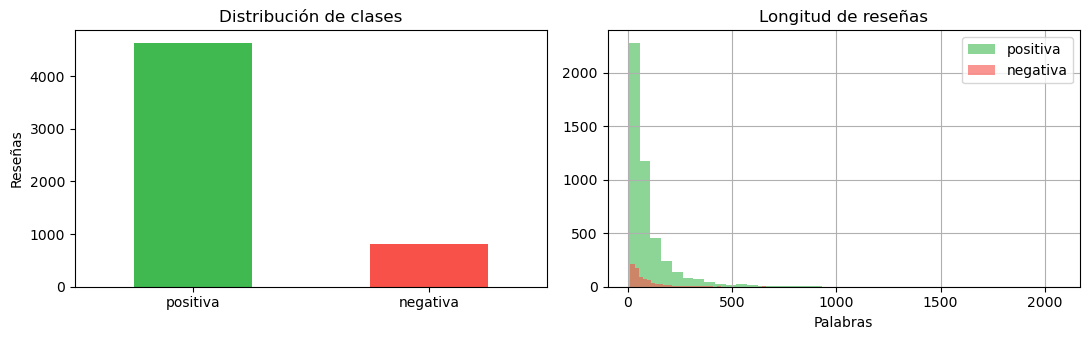

Media: 99 palabras

⭐ I’m playing on ps5 and it’s interesting.  It’s unique, massive, and has a neat story.  People are freaking out angry about this game.  I don’t think it’s a top 10 game but it’s definitely a good game on ps5 (played at launch)....

👎 Sony and Amazon are collaborating in an Auto-renew scam<br /><br />Buying this turns on Auto-renew allowing Sony to charge double the annual fee<br /><br />Sony is exploiting the financially challenged, Amazon gets kickbacks, and people who deserved ...



In [2]:
explorar_datos()

### Exploración de vocabulario

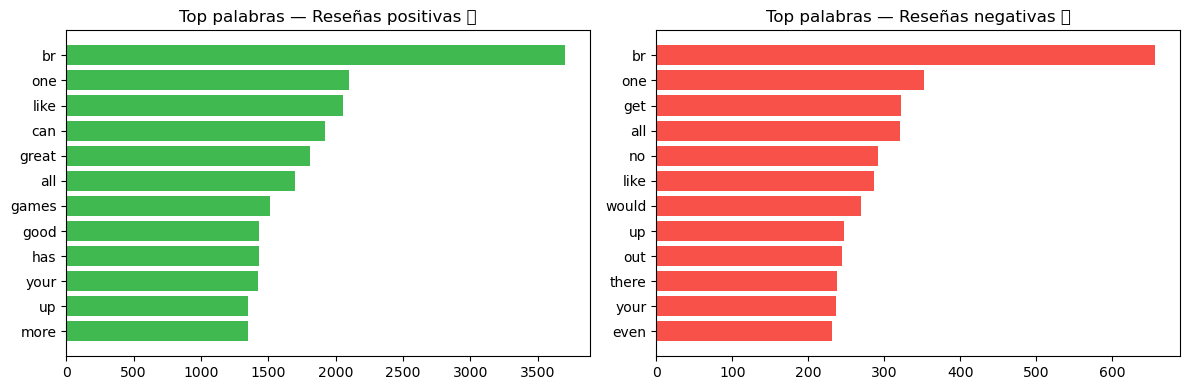

In [3]:
vocab_por_clase()

In [4]:
# Palabras del corpus que GloVe NO conoce (vocabulario de dominio puro)
vocab_corpus = set(w for t in tokens for w in t)
n_en_glove   = sum(1 for w in vocab_corpus if w in glove)
solo_w2v = sorted(
    [w for w in vocab_corpus if w not in glove and w in w2v.wv],
    key=lambda w: -w2v.wv.get_vecattr(w, 'count')
)

print(f"Vocabulario total del corpus : {len(vocab_corpus):,} palabras")
print(f"Cubiertas por GloVe          : {n_en_glove:,}  ({n_en_glove/len(vocab_corpus):.0%})")
print(f"Solo en W2V (dominio puro)   : {len(solo_w2v):,}  ({len(solo_w2v)/len(vocab_corpus):.0%})")
print(f"\nEjemplos de vocabulario que GloVe no conoce:")
print(", ".join(solo_w2v[:30]))

Vocabulario total del corpus : 22,028 palabras
Cubiertas por GloVe          : 15,758
Solo en W2V (dominio puro)   : 807

Ejemplos de vocabulario que GloVe no conoce:
it’s, i’m, don’t, itbr, i’ve, didn’t, videoid, can’t, doesn’t, gamebr, keycaps, joycons, you’re, wellbr, youve, that’s, goodbr, controllerbr, gamesbr, isn’t, thembr, clicky, consbr, timebr, amiibo, asinb, greatbr, prosbr, thisbr, badbr


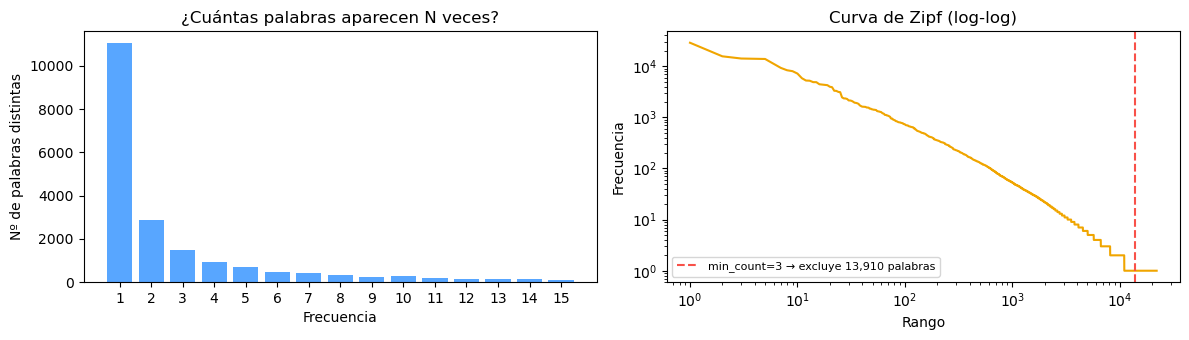

Palabras con frecuencia < 3: 13,910 / 22,028 (63%)


In [5]:
# La ley de Zipf: en cualquier corpus natural la frecuencia de una palabra
# es inversamente proporcional a su rango — la 2ª aparece la mitad de veces
# que la 1ª, la 3ª un tercio, etc. La línea roja muestra cuánto vocabulario
# se descarta con min_count=3 (la gran mayoría aparece solo 1-2 veces).
mostrar_zipf()

---
### Ejercicio — Preprocesamiento

**Objetivo:** el top 10 debería mostrar vocabulario real de jugadores:  
`play · great · good · love · fun · buy · story · graphics · recommend · worth`

Si ves `br` en las primeras posiciones, hay HTML colándose.  
Si ves `one · like · can · all · your · get · more`, son palabras vacías — añádelas a `EXTRA_STOP`.

Añade tus reglas en `limpiar()` y amplia `EXTRA_STOP` hasta que el top tenga sentido.

Top 10  ANTES: ['br', 'one', 'like', 'can', 'all', 'great', 'games', 'your', 'good', 'has']
Top 10 DESPUÉS: ['br', 'one', 'like', 'can', 'all', 'great', 'games', 'your', 'good', 'has']

Vocabulario: 22,028 → 22,028 palabras únicas

Gráfica actualizada con preprocesamiento corregido:


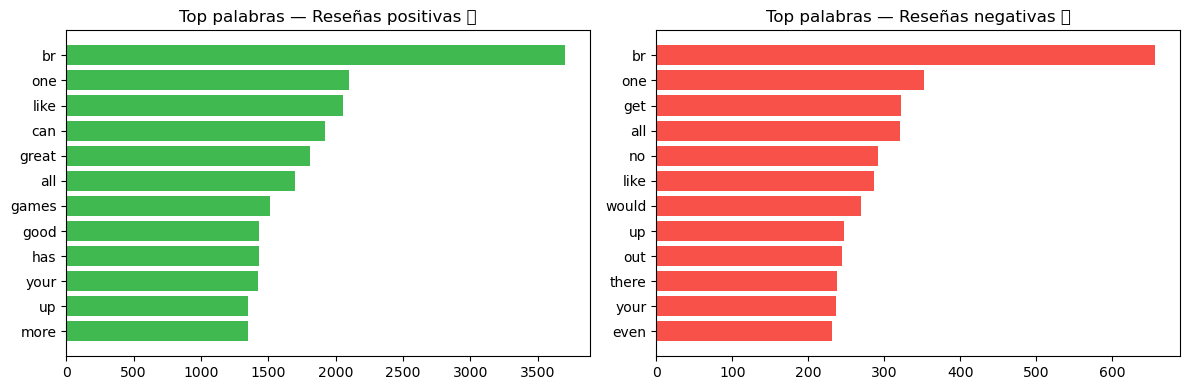

In [6]:
EXTRA_STOP = {'one', 'like', 'can', 'all', 'your', 'up', 'get',
              'more', 'when', 'out', 'use', 'has', 'would', 'also'}  # ← amplía si ves más ruido

def limpiar(texto):
    texto = str(texto).lower()
    # ── Añade aquí los pasos de limpieza que faltan ──────────────────────────


    # ─────────────────────────────────────────────────────────────────────────
    texto = re.sub(r'http\S+|\d+', ' ', texto)
    texto = texto.translate(str.maketrans('', '', string.punctuation))
    return [w for w in re.sub(r'\s+', ' ', texto).strip().split()
            if w not in EXTRA_STOP]

tokens_fix = [limpiar(t) for t in texts]

from collections import Counter
STOPWORDS = {'the','a','an','is','it','and','of','to','in','i','my','this',
             'that','was','for','with','but','on','at','not','have','are','be',
             'its','very','so','just','you','if','as','or','from','they','game'}

top_antes   = [w for w,_ in Counter(w for t in tokens     for w in t if w not in STOPWORDS|EXTRA_STOP).most_common(10)]
top_despues = [w for w,_ in Counter(w for t in tokens_fix for w in t if w not in STOPWORDS|EXTRA_STOP).most_common(10)]
print("ANTES :", top_antes)
print("DESPUÉS:", top_despues)

print("\nGráfica actualizada:")
vocab_por_clase(tokens_fix)

---
## 2. Parte I — Clasificación de sentimiento

Tres representaciones, mismo clasificador (Logistic Regression). Métrica: **F1 macro**.

Evaluando... (~1-2 min)


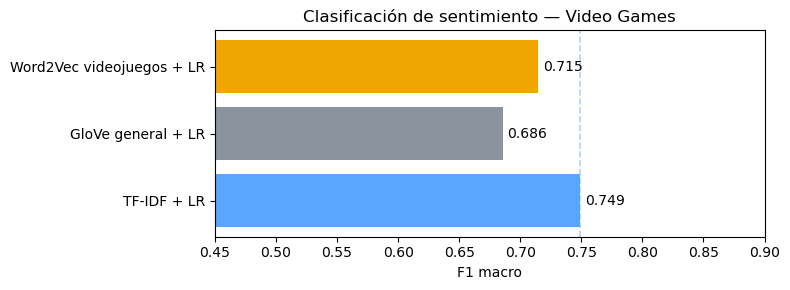

TF-IDF               F1 = 0.7491  ← referencia
GloVe general        F1 = 0.6856  (-0.0635)
W2V videojuegos      F1 = 0.7148  (-0.0343)
Mejora dominio→general:  +0.0292


In [7]:
comparar_clasificacion()

### ¿Qué nos dicen los resultados?

**W2V dominio mejora sobre GloVe general** (+0.02 pts) — especializar el modelo en el vocabulario de videojuegos ayuda, aunque TF-IDF sigue ganando.

¿Por qué TF-IDF domina? Las reseñas contienen **señales léxicas directas**: *"crashes"*, *"broken"*, *"love it"*. Promediar ~99 vectores **diluye** esas señales. TF-IDF pesa exactamente las palabras raras y discriminativas.

> La información de sentimiento está principalmente en **palabras clave individuales**, no en relaciones semánticas entre ellas.

---
## 3. Parte II — El espacio semántico del dominio

¿Qué "sabe" cada representación sobre videojuegos?

### Matriz de co-ocurrencia

Word2Vec aprende de **qué palabras aparecen juntas**. Esta matriz lo muestra directamente:
cada celda indica cuántas veces la palabra de la fila aparece cerca de la de la columna
dentro de una ventana de `window` posiciones.

Modifica `palabras_coo` para explorar distintos grupos del vocabulario,
y prueba distintos valores de `window` para ver cómo cambia la señal:

In [8]:
from collections import defaultdict

palabras_coo = ['fps', 'shooter', 'gameplay', 'graphics', 'story',
                'controls', 'fun', 'boring', 'broken', 'multiplayer']
window = 3  # ← prueba 1, 3, 7 y observa cómo cambia

coo = defaultdict(lambda: defaultdict(int))
for toks in tokens:
    for i, w in enumerate(toks):
        if w in palabras_coo:
            for ctx in toks[max(0, i-window):i] + toks[i+1:i+window+1]:
                if ctx in palabras_coo:
                    coo[w][ctx] += 1

mostrar_coo(coo, palabras_coo, window)

⚠️  La matriz está vacía — revisa la línea del contexto.


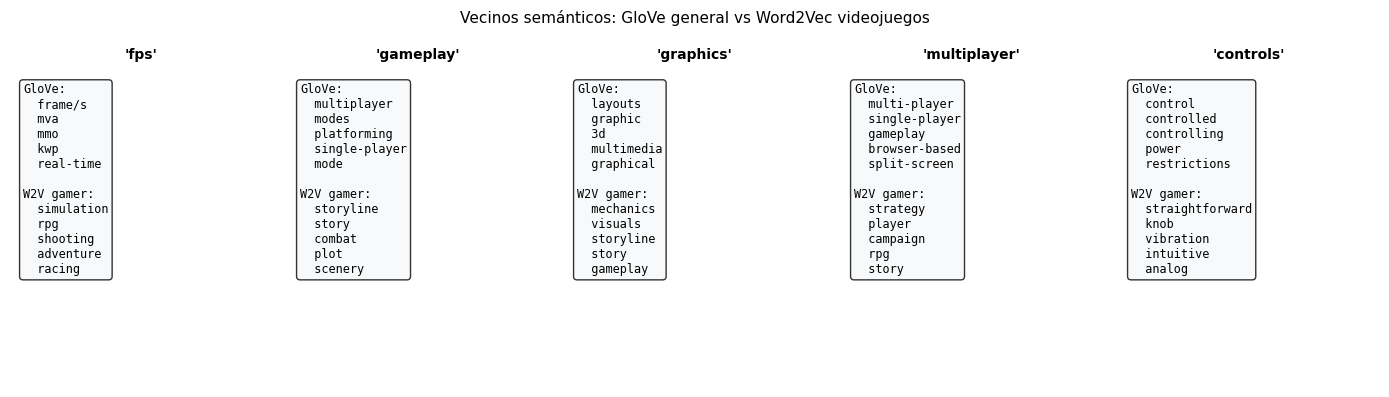

In [9]:
vecinos_semanticos(['fps', 'gameplay', 'graphics', 'multiplayer', 'controls'])

### Ejercicio — El intruso

`Word2Vec` puede identificar qué palabra no encaja con el resto comparando
su vector con el centroide del grupo.

Construye tus propias listas combinando palabras de estas categorías:

In [10]:
# Palabras disponibles en el vocabulario gaming del modelo:
categorias_vocab = {
    'Géneros':     [w for w in ['fps','shooter','rpg','racing','strategy','adventure','platformer','simulation'] if w in w2v.wv],
    'Mecánicas':   [w for w in ['gameplay','controls','multiplayer','campaign','story','graphics','mechanics','combat'] if w in w2v.wv],
    'Sentimiento': [w for w in ['fun','boring','broken','amazing','terrible','addictive','frustrating','disappointing'] if w in w2v.wv],
}
for cat, palabras in categorias_vocab.items():
    print(f"  {cat}: {palabras}")

print()
# ── Modifica las listas mezclando categorías ──────────────────────────────
listas = [
    ['fps', 'shooter', 'rpg', 'racing', 'boring'],        # género + sentimiento
    ['fun', 'amazing', 'addictive', 'great', 'fps'],       # sentimiento + género
    ['gameplay', 'controls', 'mechanics', 'graphics', 'frustrating'],  # mecánicas + sentimiento
]
for lista in listas:
    try:
        intruso = w2v.wv.doesnt_match(lista)
        print(f"{lista}")
        print(f"  → intruso: '{intruso}'  {'✅' if intruso in ['boring','fps','frustrating'] else '⚠️ inesperado — ¿por qué?'}")
    except Exception as e:
        print(f"  error: {e}")

['fps', 'shooter', 'racing', 'adventure', 'broken']  →  intruso: 'broken'
['fun', 'addictive', 'amazing', 'boring', 'great']  →  intruso: 'great'
['multiplayer', 'campaign', 'story', 'controller', 'singleplayer']  →  intruso: 'controller'


### Aritmética de vectores

Una de las propiedades más sorprendentes de los word embeddings es que las relaciones semánticas se codifican como **direcciones en el espacio vectorial**.

El ejemplo clásico: `king − man + woman ≈ queen`.  
Con nuestro vocabulario de videojuegos podemos explorar lo mismo.  
Modifica `positive` y `negative` para experimentar:

In [11]:
resultado = w2v.wv.most_similar(
    positive=['shooter', 'story'],  # sumar estos conceptos
    negative=['action'],            # restar este
    topn=6
)

print("shooter + story − action  ≈")
for palabra, sim in resultado:
    print(f"  {sim:.3f}  {palabra}")

shooter + story − action  ≈
  0.648  final
  0.598  person
  0.593  campaign
  0.576  fantasy
  0.572  movie
  0.539  playthrough


### Ejercicio — Crea tu propia analogía

Expresa una relación como `A + C − B ≈ ?` y verifica si el modelo la resuelve.

**Nota:** en corpus pequeños (~5k reseñas) las analogías son ruidosas — no siempre
funcionan aunque la relación sea real. Eso es parte de la lección: las propiedades
geométricas icónicas de Word2Vec requieren cientos de millones de tokens para ser estables.

**Sugerencias que tienden a funcionar con este corpus:**
- `rpg + shooting − magic` → ¿qué género mezcla disparos y estadísticas?
- `multiplayer + challenge − coop` → ¿qué modo implica competir solo?
- `amazing + controls − gameplay` → ¿qué aspecto valora alguien que no prioriza mecánicas?

Si el resultado no tiene sentido, prueba con otra combinación o comprueba que las palabras
están en el vocabulario con `'palabra' in w2v.wv`.

In [12]:
A = 'rpg'       # ← cambia
B = 'magic'     # ← cambia (se resta)
C = 'shooting'  # ← cambia

if all(w in w2v.wv for w in [A, B, C]):
    resultado = w2v.wv.most_similar(positive=[A, C], negative=[B], topn=5)
    print(f"'{A}' + '{C}' − '{B}'  ≈")
    for palabra, sim in resultado:
        print(f"  {sim:.3f}  {palabra}")
else:
    faltantes = [w for w in [A, B, C] if w not in w2v.wv]
    print(f"Palabras no encontradas en el vocabulario: {faltantes}")

'shooter' está a 'fps' como 'racing' está a...
  0.671  sim
  0.629  rayman
  0.615  rabbid
  0.614  karaoke
  0.603  gta


### Visualización del espacio semántico

Reducimos los vectores de 100 dimensiones a 2D con PCA para ver qué palabras quedan cerca.  
Cambia la lista `palabras` para explorar diferentes zonas del espacio:

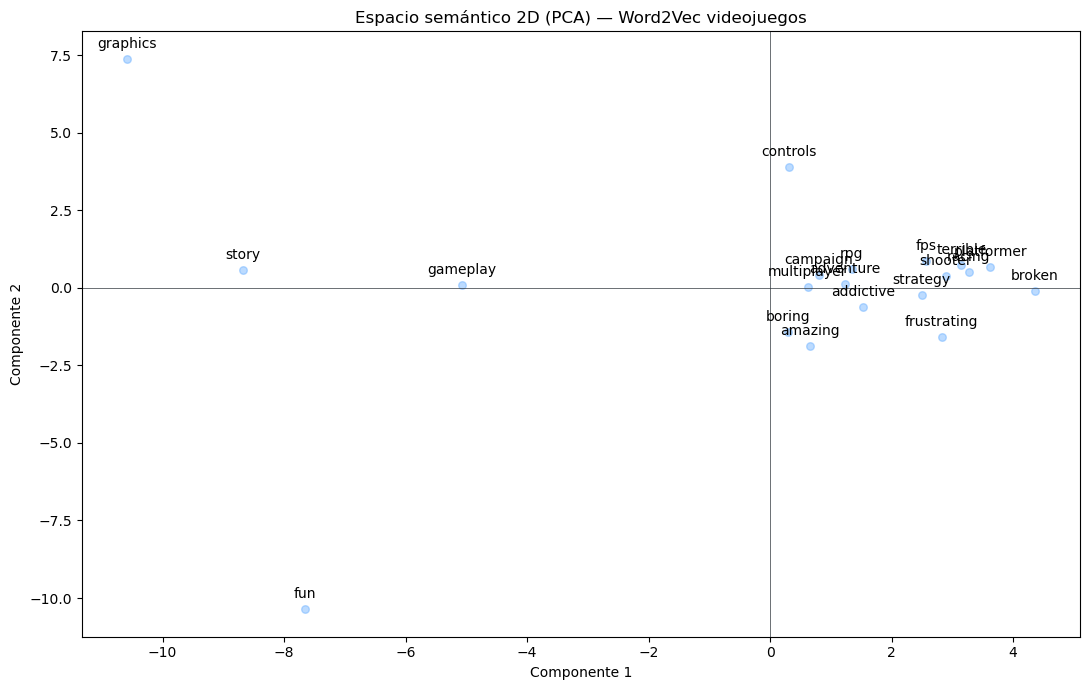

In [13]:
# Modifica la lista para explorar distintas zonas del espacio semántico
palabras = [
    'fps', 'shooter', 'racing', 'strategy', 'rpg', 'adventure', 'platformer',
    'gameplay', 'controls', 'multiplayer', 'campaign', 'story', 'graphics',
    'fun', 'addictive', 'boring', 'broken', 'amazing', 'terrible', 'frustrating',
]
visualizar_espacio(palabras)

### Ejercicio — Categorías de reseña en el espacio semántico

Fíjate en el PCA anterior: sin ninguna supervisión, Word2Vec ha separado las palabras
en zonas que corresponden a las categorías típicas de una reseña de videojuego
— gráficos, historia, jugabilidad, géneros, sentimiento.

**Tu tarea:**
1. Amplía cada lista con palabras que creas que pertenecen a esa categoría
2. Observa si caen donde esperabas en el espacio
3. Identifica palabras en zonas inesperadas — ¿por qué estarán ahí?

> **Pregunta para reflexionar:** ¿Por qué `broken` aparece cerca de `gameplay`
> y no junto a `frustrating`? ¿Qué dice eso del modelo?

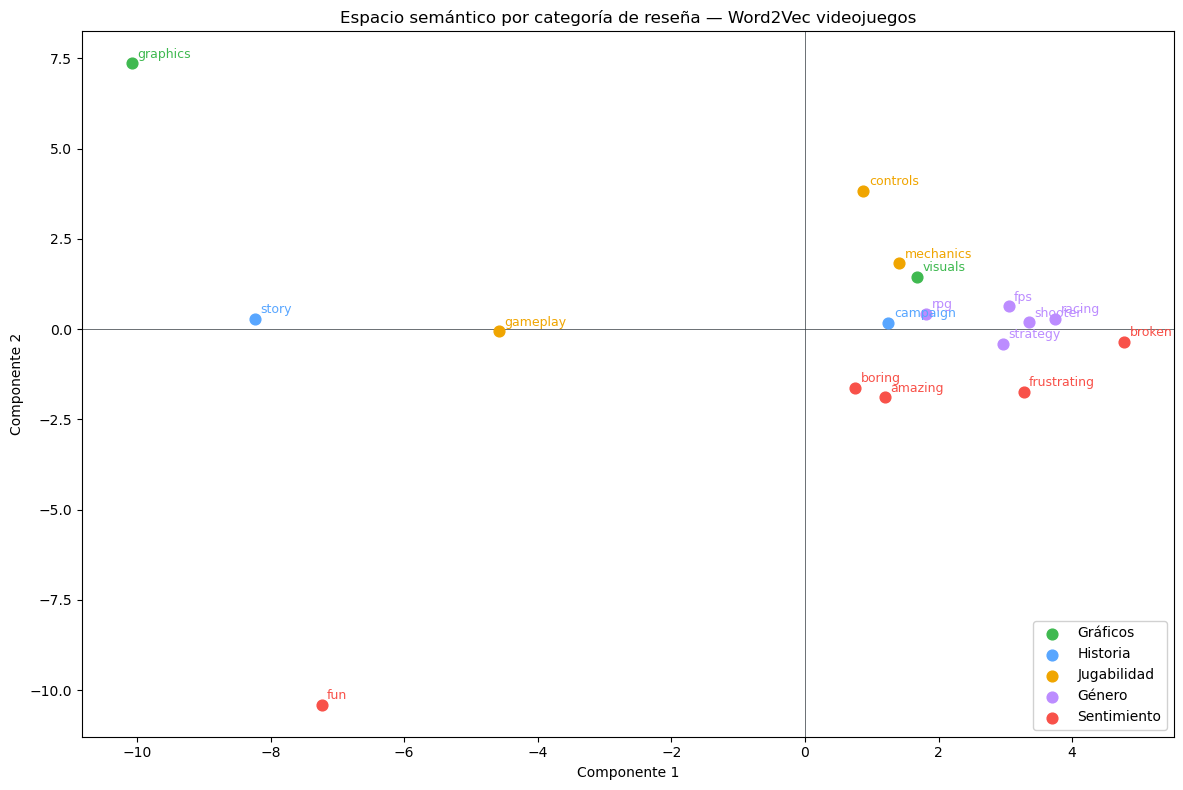

Palabras no encontradas en el vocabulario:


In [14]:
categorias = {
    'Gráficos':    ['graphics', 'visuals'],                          # ← añade más
    'Historia':    ['story', 'campaign'],                            # ← añade más
    'Jugabilidad': ['gameplay', 'controls', 'mechanics'],            # ← añade más
    'Género':      ['fps', 'shooter', 'rpg', 'racing', 'strategy'],  # ← añade más
    'Sentimiento': ['fun', 'broken', 'amazing', 'boring', 'frustrating'],  # ← añade más
}

visualizar_categorias(categorias)

---
### Ejercicio — Similitud coseno desde cero

Antes de usar la búsqueda semántica, implementa tú la métrica que la hace posible.

La similitud coseno entre dos vectores mide el ángulo entre ellos:
$$\cos(\theta) = \frac{\mathbf{v_1} \cdot \mathbf{v_2}}{\|\mathbf{v_1}\| \cdot \|\mathbf{v_2}\|}$$

Valores cercanos a **1** → palabras semánticamente próximas  
Valores cercanos a **0** → palabras no relacionadas  
Valores cercanos a **-1** → palabras opuestas

In [15]:
import numpy as np

def similitud_coseno(palabra1, palabra2, modelo=w2v.wv):
    v1 = modelo[palabra1]
    v2 = modelo[palabra2]
    numerador   = np.dot(v1, v2)
    denominador = np.linalg.norm(v1) * np.linalg.norm(v2)
    return ___  # ← una línea: combina numerador y denominador

pares = [('shooter','fps'), ('fun','boring'), ('gameplay','story'), ('amazing','terrible')]
for p1, p2 in pares:
    if p1 in w2v.wv and p2 in w2v.wv:
        print(f"  sim('{p1}', '{p2}') = {similitud_coseno(p1, p2):.4f}")

ValueError: Unknown format code 'f' for object of type 'str'

---
## 4. Parte III — Búsqueda semántica

Aquí los embeddings tienen una ventaja real: encuentran reseñas relacionadas
aunque usen **vocabulario diferente**. Prueba con una palabra de tu elección
y observa qué tipo de reseñas aparecen.

Cambia la palabra en cada celda. Prueba con términos de distintas categorías
— géneros (`fps`, `rpg`), mecánicas (`gameplay`, `controls`), sentimiento (`boring`, `amazing`) —
y observa qué reseñas emergen.

In [ ]:
buscar_visual("gameplay")

In [ ]:
buscar_visual("broken")

In [ ]:
buscar_visual("story")

**Tu turno** — escribe cualquier palabra del vocabulario gaming:

In [ ]:
buscar_visual("fps")  # ← cambia esta palabra

### Ejercicio — Implementa la búsqueda semántica

`avg_vecs(tokens, modelo)` está definida en el setup: recibe una lista de tokens
y devuelve el **vector promedio** de las palabras que existen en el modelo.

```python
avg_vecs(['broken', 'gameplay'], w2v.wv)  # → array de 100 dimensiones
```

Tu tarea: úsala para convertir la query en un vector y calcular su similitud
con todos los documentos. El resto del código ya está dado.

In [ ]:
def mi_buscar(query, top_k=4):
    q_tok = tok(query)
    q_vec = ___  # ← avg_vecs con los tokens de la query y w2v.wv

    similitudes = cosine_similarity(q_vec.reshape(1, -1), X_w2v)[0]
    top_idx     = similitudes.argsort()[-top_k:][::-1]

    print(f"\n🔍 '{query}'")
    for i in top_idx:
        print(f"  {'⭐' if labels[i] else '👎'}  {texts[i][:115]}")

mi_buscar("game with great story")
mi_buscar("broken controls frustrating")

### Promedio simple vs ponderado TF-IDF

Con el promedio simple todas las palabras contribuyen igual al vector de la query.
Con ponderación TF-IDF las palabras **raras e informativas** pesan más.

¿Cambia el resultado para la misma query?

In [ ]:
def buscar_comparar(query, top_k=3):
    q_tok = tok(query)

    # Promedio simple
    q_simple = avg_vecs(q_tok, w2v.wv).reshape(1, -1)
    idx_s = cosine_similarity(q_simple, X_w2v)[0].argsort()[-top_k:][::-1]

    # Ponderado TF-IDF
    try:
        q_pond = weighted_avg_vecs(q_tok, w2v.wv, vocab_idf).reshape(1, -1)
        idx_p  = cosine_similarity(q_pond, X_w2v)[0].argsort()[-top_k:][::-1]
        tiene_pond = True
    except NameError:
        tiene_pond = False

    print(f"Query: '{query}'\n")
    print("  Promedio simple:")
    for i in idx_s:
        print(f"    {'⭐' if labels[i] else '👎'} {texts[i][:100]}")

    if tiene_pond:
        print("\n  Ponderado TF-IDF:")
        for i in idx_p:
            marker = "← nuevo" if i not in list(idx_s) else ""
            print(f"    {'⭐' if labels[i] else '👎'} {texts[i][:100]}  {marker}")
        nuevos = [i for i in idx_p if i not in list(idx_s)]
        print(f"\n  → {len(nuevos)}/{top_k} resultado(s) distintos con ponderación")
    else:
        print("\n  (ejecuta primero el ejercicio de embeddings ponderados)")

buscar_comparar("broken gameplay frustrating")
buscar_comparar("amazing graphics story")

---
## 5. Reto — Entrena tu propio Word2Vec

El W2V del setup usa los hiperparámetros por defecto. ¿Puedes mejorarlo?

Entrena tu propio modelo cambiando uno o varios parámetros y usa `evaluar_w2v()` para ver si mejora el F1.

| Parámetro | Descripción | Valores a probar |
|---|---|---|
| `vector_size` | Dimensión de los vectores | 50, 100, 200, 300 |
| `window` | Palabras de contexto a cada lado | 3, 5, 10 |
| `min_count` | Frecuencia mínima de una palabra | 1, 3, 5 |
| `sg` | Arquitectura: `0`=CBOW, `1`=Skip-gram | 0, 1 |
| `epochs` | Iteraciones sobre el corpus | 10, 20, 50 |

> **Pista:** Skip-gram (`sg=1`) suele funcionar mejor con vocabulario de nicho y corpus pequeños.

In [ ]:
mi_w2v = Word2Vec(
    sentences=tokens,   # corpus — no cambiar
    vector_size=100,    # ← tunea
    window=5,           # ← tunea
    min_count=3,        # ← tunea
    sg=0,               # ← 0=CBOW, 1=Skip-gram
    epochs=20,          # ← tunea
    workers=1,          # no cambiar
    seed=42
)

evaluar_w2v(mi_w2v, nombre="Mi W2V")

### Ejercicio — Embeddings ponderados por TF-IDF

El promedio simple trata todas las palabras igual.
Una mejora natural: ponderar cada vector por el peso TF-IDF de la palabra —
así los términos más informativos contribuyen más al vector del documento.

`vocab_idf` ya contiene el IDF de cada palabra del corpus.

In [ ]:
def weighted_avg_vecs(toks, modelo, idf_dict, dim=100):
    vecs, pesos = [], []
    for w in toks:
        if w in modelo and w in idf_dict:
            vecs.append(modelo[w])
            pesos.append(idf_dict[w])
    if not vecs:
        return np.zeros(dim)
    pesos = np.array(pesos)
    pesos = ___  # ← una línea: normaliza para que sumen 1
    return np.average(vecs, axis=0, weights=pesos)

X_ponderado = np.array([weighted_avg_vecs(t, w2v.wv, vocab_idf) for t in tokens])
s_ponderado = cross_val_score(lr, X_ponderado, labels, cv=cv, scoring=f1_mac).mean()
print(f"W2V promedio simple    F1 = {s_w2:.4f}")
print(f"W2V ponderado TF-IDF  F1 = {s_ponderado:.4f}  ({s_ponderado - s_w2:+.4f})")

---
## Epílogo — ¿Qué consigue un transformer?

Todo lo que hemos visto hasta aquí usa representaciones estáticas: cada palabra tiene un vector fijo
independientemente del contexto en que aparezca.

`"not great"` → W2V lo procesa como el promedio de `not` + `great` → vector ambiguo  
`"not great"` → DistilBERT lo lee como secuencia y entiende la negación

El código de abajo carga un modelo preentrenado en sentimiento y lo evalúa directamente
sobre nuestras reseñas **sin haberlas visto nunca** (zero-shot).  
Puede tardar ~2 minutos — es normal, los transformers son más lentos que LR.

In [ ]:
from transformers import pipeline
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline as SKPipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

N = 300  # subconjunto para que sea ejecutable en clase
texts_n, labels_n, tokens_n = texts[:N], labels[:N], tokens[:N]
clean_n = [' '.join(t) for t in tokens_n]

# Modelos clásicos sobre el mismo subconjunto
lr = LogisticRegression(C=5, max_iter=1000, random_state=42)
s_tf_n = cross_val_score(SKPipeline([('t',TfidfVectorizer()),('l',lr)]),
                         clean_n, labels_n, cv=5, scoring=f1_mac).mean()
X_w2v_n = np.array([avg_vecs(t, w2v.wv) for t in tokens_n])
s_w2_n  = cross_val_score(lr, X_w2v_n, labels_n, cv=5, scoring=f1_mac).mean()

# DistilBERT zero-shot
print("Cargando DistilBERT... (~1 min primera vez)")
clf = pipeline("sentiment-analysis",
               model="distilbert-base-uncased-finetuned-sst-2-english",
               truncation=True, max_length=512)
preds  = clf(texts_n, batch_size=16)
y_bert = [1 if p['label'] == 'POSITIVE' else 0 for p in preds]
s_bert = f1_score(labels_n, y_bert, average='macro')

mostrar_comparativa_final({
    'TF-IDF + LR':             s_tf_n,
    'Word2Vec dominio + LR':   s_w2_n,
    'DistilBERT (zero-shot)':  s_bert,
})
print(f"\nDistilBERT mejora {s_bert - s_w2_n:+.3f} sobre W2V dominio")
print("...y nunca vio una reseña de videojuegos.")
print("\nEn el Módulo 5 veremos qué ocurre cuando SÍ la fine-tuneamos sobre nuestros datos.")

---
## Conclusión

| | TF-IDF | GloVe general | W2V videojuegos |
|---|---|---|---|
| Clasificación sentimiento | ✅ Mejor | ❌ | ➡️ Mejora sobre GloVe |
| Vocabulario de dominio | ❌ | ❌ Genérico | ✅ Entiende gaming |
| Búsqueda semántica | ❌ Solo léxico | ➡️ | ✅ Semántico + dominio |

**Especializar mejora**, pero el promedio de vectores tiene límites en sentimiento. Para lo mejor de los dos mundos — comprensión contextual + especialización de dominio — necesitamos transformers fine-tuned. Lo veremos en el **Módulo 5**.

---
### ¿Por qué la mejora del dominio es modesta?

Especializar Word2Vec mejora los vecinos semánticos de forma clara — `fps` pasa de asociarse con hardware a asociarse con géneros de juego. Sin embargo, en la métrica de clasificación la ganancia es pequeña, y tiene una explicación directa.

GloVe fue entrenado sobre **6.000 millones de tokens**; nuestro W2V, sobre ~6.000 reseñas. Con esa diferencia de escala, la estabilidad geométrica de GloVe compensa su falta de especialización. Además, Word2Vec aprende a predecir palabras de contexto — no sentimiento — así que incluso vectores perfectamente especializados no codifican polaridad directamente. Y el promedio de 99 vectores sigue diluyendo las señales léxicas de sentimiento independientemente de su calidad individual.

Estos tres límites — **escala de datos**, **objetivo de entrenamiento** y **agregación por promedio** — son precisamente los que los transformers resuelven a la vez: preentrenamiento masivo, fine-tuning con la señal de la tarea, y atención sobre la secuencia completa.